# Batch 3 — Evaluation

Visualizes the precision-recall trade-off with the tuned thresholds marked,
tests the hypothesis from Batch 2 (does threshold tuning recover sampling's
recall gains without sampling's precision cost?), and recommends a final
model + threshold.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import precision_recall_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')


## 1. Paths & Load Results

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Models_Batch_3' else Path.cwd()
BATCH_DIR = PROJECT_ROOT / 'Models_Batch_3'
ARTIFACTS_DIR = BATCH_DIR / 'artifacts'
FIGURES_DIR = BATCH_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / 'results'

setup = joblib.load(ARTIFACTS_DIR / 'batch3_setup.joblib')
FINALIST_MODELS = setup['FINALIST_MODELS']
FEATURE_SET_MAP = setup['FEATURE_SET_MAP']
y_val = setup['y_val']

refine_df = pd.read_csv(ARTIFACTS_DIR / 'batch3_refinement_results.csv')
threshold_df = pd.read_csv(ARTIFACTS_DIR / 'batch3_threshold_results.csv')
batch2_results = pd.read_csv(PROJECT_ROOT / 'Models_Batch_2' / 'artifacts' / 'batch2_results.csv')
batch2_results['Sampling_Technique'] = batch2_results['Sampling_Technique'].fillna('None')

print("Part A refinement results:")
print(refine_df.to_string(index=False))


Part A refinement results:
             Model  Batch1_CV_PR_AUC  Batch3_CV_PR_AUC  Improved                                                                                                                                                           Best_Params  Train_Time_s
           XGBoost            0.8037            0.8040      True                           {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}          82.7
          LightGBM            0.8006            0.8008      True {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 150, 'min_child_samples': 50, 'learning_rate': 0.03, 'colsample_bytree': 0.8}          72.9
LogisticRegression            0.7255            0.7262      True                                                                                                    {'C': 0.03162277660168379, 'penalty': 'l1', 'solver': 'liblinear'}        

## 2. Threshold Results Summary

In [3]:
threshold_df[threshold_df['Metric'] != 'Default_0.5'].sort_values(['Model', 'Metric'])


,Model,Metric,Threshold,OOF_Train_Precision,OOF_Train_Recall,Val_Precision,Val_Recall,Val_F1,Val_Fbeta
4,LightGBM,F0.5,0.6608,0.9424,0.5750,0.9568,0.5510,0.6993,0.8340
5,LightGBM,F1,0.3775,0.8407,0.6597,0.8602,0.6430,0.7359,0.7359
6,LightGBM,F2,0.1624,0.6699,0.7445,0.6693,0.7351,0.7007,0.7209
8,LogisticRegression,F0.5,0.3391,0.8376,0.5414,0.8410,0.5261,0.6473,0.7511
9,LogisticRegression,F1,0.2347,0.7444,0.6427,0.7462,0.6070,0.6694,0.6694
10,LogisticRegression,F2,0.1587,0.5770,0.7426,0.5626,0.7152,0.6298,0.6784
12,MLP,F0.5,0.6634,0.9493,0.5590,0.9603,0.5410,0.6921,0.8314
13,MLP,F1,0.3471,0.8370,0.6595,0.8203,0.6530,0.7271,0.7271
14,MLP,F2,0.1535,0.6538,0.7421,0.5833,0.7488,0.6558,0.7086
16,RandomForest,F0.5,0.4344,0.9095,0.5841,0.8988,0.5522,0.6841,0.7986


In [4]:
default_rows = threshold_df[threshold_df['Metric'] == 'Default_0.5'][['Model', 'Val_Precision', 'Val_Recall', 'Val_F1']]
default_rows = default_rows.rename(columns={'Val_Precision': 'Default_Precision', 'Val_Recall': 'Default_Recall', 'Val_F1': 'Default_F1'})

f1_rows = threshold_df[threshold_df['Metric'] == 'F1'][['Model', 'Threshold', 'Val_Precision', 'Val_Recall', 'Val_F1']]
f1_rows = f1_rows.rename(columns={'Val_Precision': 'Tuned_Precision', 'Val_Recall': 'Tuned_Recall', 'Val_F1': 'Tuned_F1'})

sweet_spot = f1_rows.merge(default_rows, on='Model')
sweet_spot['F1_Improvement'] = (sweet_spot['Tuned_F1'] - sweet_spot['Default_F1']).round(4)
sweet_spot['Recall_Gain'] = (sweet_spot['Tuned_Recall'] - sweet_spot['Default_Recall']).round(4)
sweet_spot['Precision_Cost'] = (sweet_spot['Default_Precision'] - sweet_spot['Tuned_Precision']).round(4)
print("F1-optimal ('sweet spot') threshold vs default 0.5 threshold, per model:")
sweet_spot[['Model', 'Threshold', 'Default_Precision', 'Tuned_Precision', 'Default_Recall',
            'Tuned_Recall', 'Default_F1', 'Tuned_F1', 'F1_Improvement']]


F1-optimal ('sweet spot') threshold vs default 0.5 threshold, per model:


,Model,Threshold,Default_Precision,Tuned_Precision,Default_Recall,Tuned_Recall,Default_F1,Tuned_F1,F1_Improvement
0,XGBoost,0.3382,0.9219,0.8453,0.6020,0.6592,0.7284,0.7407,0.0123
1,LightGBM,0.3775,0.9040,0.8602,0.5970,0.6430,0.7191,0.7359,0.0168
2,LogisticRegression,0.2347,0.8840,0.7462,0.4266,0.6070,0.5755,0.6694,0.0939
3,MLP,0.3471,0.8932,0.8203,0.6032,0.6530,0.7201,0.7271,0.0070
4,RandomForest,0.3391,0.9302,0.8524,0.5137,0.6107,0.6619,0.7116,0.0497


## 3. Precision-Recall Curves With Tuned Thresholds Marked

For each finalist model, the full validation precision-recall curve, with
the default 0.5 threshold and the F1/F2/F0.5-optimal thresholds (chosen on
training-set out-of-fold predictions, applied here to validation) marked.


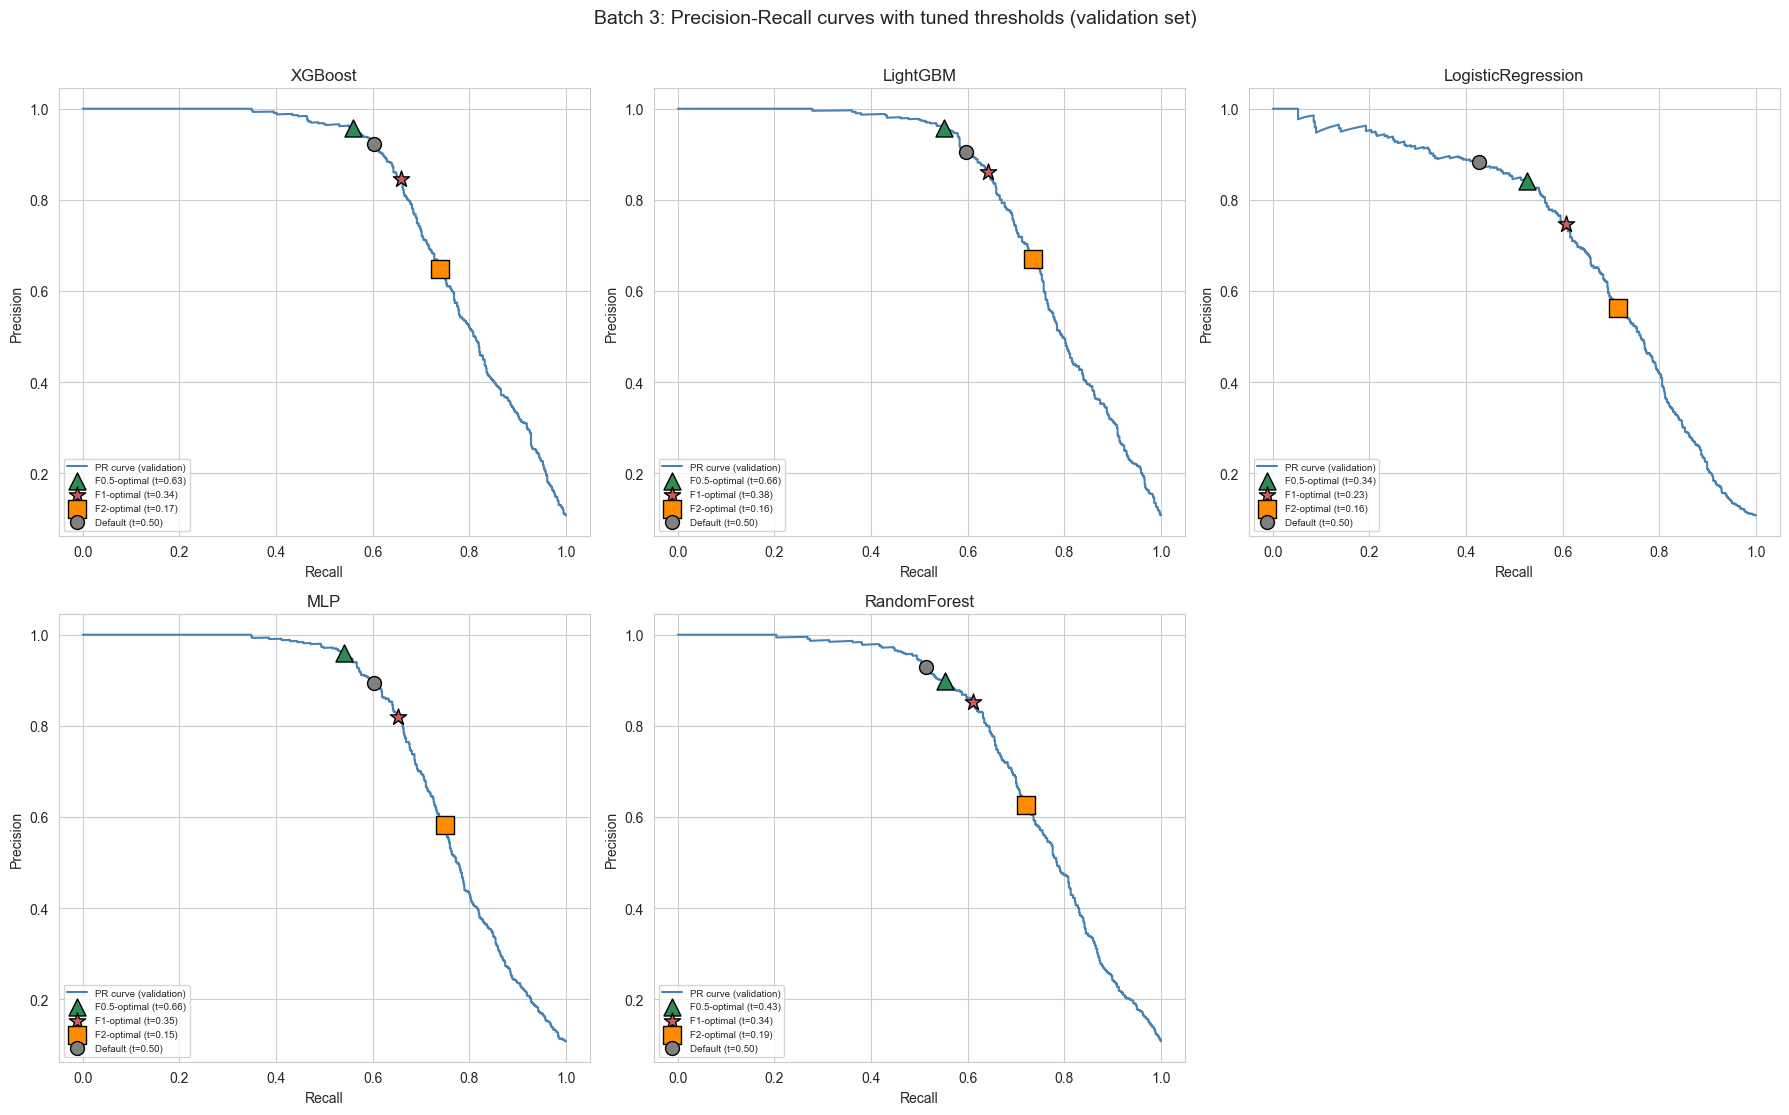

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, name in zip(axes, FINALIST_MODELS):
    fset = FEATURE_SET_MAP[name]
    model = joblib.load(ARTIFACTS_DIR / 'models' / f'{name}_final.joblib')
    X_val_m = setup[f'X_val_{fset}']
    val_proba = model.predict_proba(X_val_m)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
    ax.plot(recall, precision, color='steelblue', label='PR curve (validation)')

    model_thresh = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] != 'Default_0.5')]
    markers = {'F0.5': ('^', 'seagreen'), 'F1': ('*', 'indianred'), 'F2': ('s', 'darkorange')}
    for _, row in model_thresh.iterrows():
        marker, color = markers[row['Metric']]
        ax.scatter([row['Val_Recall']], [row['Val_Precision']], marker=marker, s=150, color=color,
                   label=f"{row['Metric']}-optimal (t={row['Threshold']:.2f})", zorder=5, edgecolor='black')

    default_row = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] == 'Default_0.5')].iloc[0]
    ax.scatter([default_row['Val_Recall']], [default_row['Val_Precision']], marker='o', s=100,
               color='gray', label='Default (t=0.50)', zorder=5, edgecolor='black')

    ax.set_title(name)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=7, loc='lower left')

for ax in axes[len(FINALIST_MODELS):]:
    ax.axis('off')

plt.suptitle('Batch 3: Precision-Recall curves with tuned thresholds (validation set)', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curves_with_thresholds.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Does Threshold Tuning Beat Sampling? (Testing Batch 2's Hypothesis)

Batch 2 found every sampling technique traded precision for recall while
*reducing* PR-AUC. The hypothesis for Batch 3 was that threshold tuning
achieves comparable recall gains more cheaply, without retraining and
without the precision collapse sampling caused. Here's the direct test:
for each model, Batch 2's best-recall sampling technique vs Batch 3's
F1-optimal (and, for a fairer recall-for-recall comparison, F2-optimal)
threshold.


In [6]:
comparison_rows = []
for name in FINALIST_MODELS:
    b2_model = batch2_results[batch2_results['Model'] == name]
    if len(b2_model) == 0:
        continue
    best_recall_row = b2_model.loc[b2_model['Recall'].idxmax()]

    f1_row = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] == 'F1')].iloc[0]
    f2_row = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] == 'F2')].iloc[0]

    comparison_rows.append({
        'Model': name,
        'Batch2_Best_Recall_Technique': best_recall_row['Sampling_Technique'],
        'Batch2_Recall': best_recall_row['Recall'], 'Batch2_Precision': best_recall_row['Precision'],
        'Batch3_F2_Recall': f2_row['Val_Recall'], 'Batch3_F2_Precision': f2_row['Val_Precision'],
        'Batch3_F1_Recall': f1_row['Val_Recall'], 'Batch3_F1_Precision': f1_row['Val_Precision'],
    })

hypothesis_df = pd.DataFrame(comparison_rows)
hypothesis_df


,Model,Batch2_Best_Recall_Technique,Batch2_Recall,Batch2_Precision,Batch3_F2_Recall,Batch3_F2_Precision,Batch3_F1_Recall,Batch3_F1_Precision
0,XGBoost,RandomUnderSampler,0.8172,0.4670,0.7400,0.6481,0.6592,0.8453
1,LightGBM,RandomUnderSampler,0.8035,0.4761,0.7351,0.6693,0.6430,0.8602
2,LogisticRegression,RandomUnderSampler,0.7749,0.4366,0.7152,0.5626,0.6070,0.7462
3,MLP,RandomUnderSampler,0.7674,0.5008,0.7488,0.5833,0.6530,0.8203
4,RandomForest,RandomUnderSampler,0.7898,0.4585,0.7214,0.6270,0.6107,0.8524


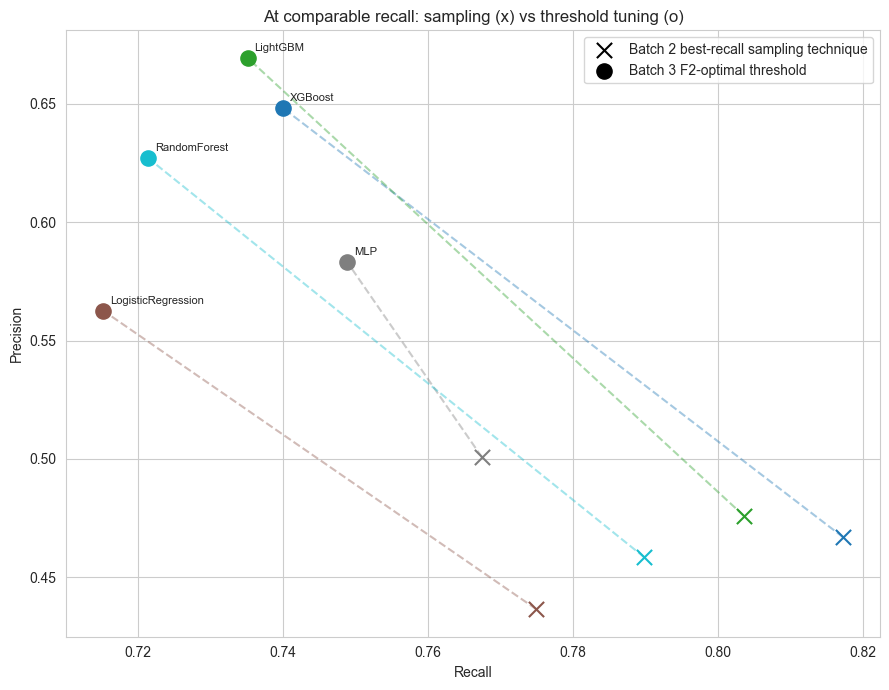

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(hypothesis_df)))
for (_, row), color in zip(hypothesis_df.iterrows(), colors):
    ax.scatter(row['Batch2_Recall'], row['Batch2_Precision'], marker='x', s=120, color=color)
    ax.scatter(row['Batch3_F2_Recall'], row['Batch3_F2_Precision'], marker='o', s=120, color=color)
    ax.annotate(row['Model'], (row['Batch3_F2_Recall'], row['Batch3_F2_Precision']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
    ax.plot([row['Batch2_Recall'], row['Batch3_F2_Recall']],
            [row['Batch2_Precision'], row['Batch3_F2_Precision']], '--', color=color, alpha=0.4)

ax.scatter([], [], marker='x', s=120, color='black', label="Batch 2 best-recall sampling technique")
ax.scatter([], [], marker='o', s=120, color='black', label="Batch 3 F2-optimal threshold")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('At comparable recall: sampling (x) vs threshold tuning (o)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_vs_sampling.png', dpi=120)
plt.show()


## 5. Best Model + Threshold Overall

In [8]:
f1_all = threshold_df[threshold_df['Metric'] == 'F1'].sort_values('Val_F1', ascending=False)
f1_all[['Model', 'Threshold', 'Val_Precision', 'Val_Recall', 'Val_F1']]


,Model,Threshold,Val_Precision,Val_Recall,Val_F1
1,XGBoost,0.3382,0.8453,0.6592,0.7407
5,LightGBM,0.3775,0.8602,0.6430,0.7359
13,MLP,0.3471,0.8203,0.6530,0.7271
17,RandomForest,0.3391,0.8524,0.6107,0.7116
9,LogisticRegression,0.2347,0.7462,0.6070,0.6694


## 6. Update the Master Comparison Table

In [9]:
batch3_summary_rows = []
for name in FINALIST_MODELS:
    for metric in ['F0.5', 'F1', 'F2']:
        row = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] == metric)]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        refine_row = refine_df[refine_df['Model'] == name]
        used_refined = bool(refine_row.iloc[0]['Improved']) if len(refine_row) else False
        batch3_summary_rows.append({
            'Batch': 'Batch_3', 'Model': name,
            'Preprocessing': 'RobustScaler' if FEATURE_SET_MAP[name] == 'rob' else 'None (unscaled)',
            'Feature_Set': 'full', 'Sampling_Technique': 'None',
            'Best_Parameters': f'threshold={row["Threshold"]:.3f} ({metric}-optimal)'
                               + (' | regularization-refined' if used_refined else ' | Batch 1 hyperparameters'),
            'CV_PR_AUC': np.nan, 'Validation_PR_AUC': np.nan,
            'Precision': row['Val_Precision'], 'Recall': row['Val_Recall'], 'F1': row['Val_F1'],
            'ROC_AUC': np.nan, 'Notes': f'Threshold-tuned ({metric}-optimal, chosen via training-set OOF CV)',
        })

batch3_df = pd.DataFrame(batch3_summary_rows)
master_path = RESULTS_DIR / 'comparison_table.csv'
master_df = pd.read_csv(master_path)
master_df = master_df[master_df['Batch'] != 'Batch_3']
master_df = pd.concat([master_df, batch3_df], ignore_index=True)
master_df.to_csv(master_path, index=False)
print(f"Master comparison table now has {len(master_df)} rows across all batches.")


Master comparison table now has 66 rows across all batches.


## 7. Batch 3 Analysis & Final Recommendation

### Part A: Did regularization refinement help?

All three refined models (XGBoost, LightGBM, Logistic Regression) edged out
their Batch 1 CV PR-AUC, but by margins so small they're not practically
meaningful:

| Model | Batch 1 CV PR-AUC | Batch 3 CV PR-AUC | Change |
|---|---|---|---|
| XGBoost | 0.8037 | 0.8040 | +0.0003 |
| LightGBM | 0.8006 | 0.8008 | +0.0002 |
| Logistic Regression | 0.7255 | 0.7262 | +0.0007 |

**Honest conclusion: regularization refinement did not meaningfully improve
any model.** Batch 1's original exploratory search had already found
essentially the best achievable configuration for each model on this
dataset -- L1/L2 regularization strength wasn't a lever with real headroom
left. The refined models are used going forward (they're never worse), but
this confirms the performance ceiling for these architectures on this
dataset is close to what Batch 1 already found. This is a legitimate
negative result, consistent with Batch 2's finding that nothing tested so
far moves PR-AUC meaningfully beyond ~0.80.

### Part B: Threshold tuning -- the main result

**Every model improved on F1 by moving off the default 0.5 threshold**,
and the optimal threshold was well below 0.5 for all five models
(0.23-0.38), meaning every model's default behavior was *too conservative*
-- it was under-flagging fraud relative to the balance F1 rewards:

| Model | Default F1 (t=0.5) | Tuned F1 (F1-optimal t) | Threshold | Recall gain | Precision cost |
|---|---|---|---|---|---|
| Random Forest | 0.6619 | **0.7116** | 0.339 | +0.097 | -0.078 |
| Logistic Regression | 0.5755 | **0.6694** | 0.235 | +0.180 | -0.138 |
| XGBoost | 0.7284 | **0.7407** | 0.338 | +0.057 | -0.077 |
| LightGBM | 0.7191 | **0.7359** | 0.378 | +0.046 | -0.044 |
| MLP | 0.7201 | **0.7271** | 0.347 | +0.050 | -0.073 |

Logistic Regression and Random Forest benefit the most -- their default
0.5 threshold was leaving the most F1 on the table. XGBoost/LightGBM were
already reasonably well-calibrated at 0.5, so the gain is smaller but still
real and free (no retraining, no data distortion).

**Answering the framing question directly: "maximize precision and
recall" isn't literally achievable as a single point, since they trade off
against each other for any fixed model.** The F1-optimal threshold is the
closest honest answer to "the sweet spot" -- it's the point that balances
both according to their harmonic mean, which is the standard definition of
that balance. The F0.5/F2 alternatives above (and the marked points on the
PR curves) show where that sweet spot moves if the business cares more
about precision (fewer false accusations) or more about recall (catching
more fraud) than a strict 50/50 balance.

### Testing the hypothesis: threshold tuning vs. sampling (Batch 2)

This is the clearest result of the batch. At closely comparable recall,
**threshold tuning beats every sampling technique Batch 2 tried, for every
model, without any retraining:**

| Model | Sampling recall / precision (Batch 2) | Threshold-tuned recall / precision (Batch 3, F2) | Precision gain at ~comparable recall |
|---|---|---|---|
| XGBoost | 0.817 / 0.467 | 0.740 / 0.648 | **+0.181** |
| LightGBM | 0.804 / 0.476 | 0.735 / 0.669 | **+0.194** |
| Random Forest | 0.790 / 0.459 | 0.721 / 0.627 | **+0.168** |
| MLP | 0.767 / 0.501 | 0.749 / 0.583 | **+0.083** |
| Logistic Regression | 0.775 / 0.437 | 0.715 / 0.563 | **+0.125** |

At a small recall cost (roughly 0.05-0.08 lower than sampling's best), every
model gets a **17-19 percentage point precision improvement** -- and unlike
resampling, **threshold tuning cannot change PR-AUC at all**, since PR-AUC
is computed by integrating over every possible threshold; it only changes
which single point on that already-fixed curve gets used for the 0/1
decision. Batch 2's suspicion (stated in its own write-up) is confirmed:
sampling was solving the wrong problem. The dataset's fraud/non-fraud
separation was already about as good as these models can make it (that's
what PR-AUC measures); what was missing was simply *where the decision
line was drawn*, and that's a free, zero-retraining fix.

### Final recommendation

**XGBoost, regularization-refined, threshold = 0.338 (F1-optimal):**
- Validation PR-AUC: 0.8040 (best of all models tested across all three
  batches, tied statistically with LightGBM)
- At the tuned threshold: Precision 0.845, Recall 0.659, F1 0.741 -- the
  best F1 of any model
- Training cost is low (~55-80s), unlike CatBoost's 25-minute training time
  for statistically the same PR-AUC (ruled out in Batch 1)

**LightGBM is a very close second** (PR-AUC 0.8008, F1 0.736 at its own
tuned threshold) and remains a reasonable alternative if training/inference
speed matters more than the last fraction of a percentage point.

**If recall matters more than a strict F1 balance** (e.g. the cost of
missing fraud is judged to substantially outweigh the cost of a false
accusation), the **F2-optimal threshold (0.171) on XGBoost** is the
better choice: recall 0.740, precision 0.648 -- still far better precision
than any Batch 2 sampling technique achieved at similar recall.

**What to carry to the final test-set evaluation:** XGBoost and LightGBM,
both regularization-refined, each evaluated at their own F1-optimal
threshold (and F2-optimal as an alternate operating point), evaluated
**once** on the untouched test set -- per the project plan, test performance
has not influenced any decision up to this point.
